# CPU vs GPU Inference Benchmark - All 6 Model Configurations

This notebook measures the average per-image inference latency, on both CPU and GPU, for
all six model configurations compared in the thesis (Standard EfficientNet-B0, DeiT-Tiny,
EfficientNet-B0 gated, DINOv3 ConvNeXt-S, Dual-Branch ablation (CNN+DINOv3 ViT-S), Dual-Branch
final (Hybrid+DINOv3 ViT-S)).

Inference latency depends only on the **architecture** (number of operations per forward
pass), not on the learned weight values, so every model here is instantiated fresh
(pretrained backbone weights where applicable, randomly-initialized classification head) --
no dataset, no Drive, no `.pth` checkpoint is required. This notebook is fully standalone
and can be run on a plain Colab session.

Timing covers only the forward pass (`model(x)`), batch size 1 on a single 224x224 image,
matching the realistic per-frame inference scenario used for the final model's benchmark
(Chapter 3 of the thesis). Run on a Colab **GPU runtime** (Runtime > Change runtime type > GPU)
to get both CPU and GPU numbers from a single run (the CPU cores stay available in a GPU
runtime).

**Note:** DINOv3 checkpoints on HuggingFace are gated. Accept the license for both
https://huggingface.co/facebook/dinov3-convnext-small-pretrain-lvd1689m and
https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m and have a read-access token
ready before running the login cell below.

In [1]:
%pip install -q transformers huggingface_hub accelerate timm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import timm
from torchvision import models
from transformers import AutoModel
from huggingface_hub import login

SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
# Log in to HuggingFace Hub to access the gated DINOv3 checkpoints (needed for models
# 4, 5 and 6 below)
login()

In [3]:
# --- Model 1: Standard EfficientNet-B0 (Model_Benchmark/CNN_ViT_Hybrid/step1_baseline.ipynb) ---
class StandardEfficientNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.model = models.efficientnet_b0(weights=weights)
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


# --- Model 2: DeiT-Tiny (Model_Benchmark/CNN_ViT_Hybrid/step1_baseline.ipynb) ---
class DeitTiny(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.model = timm.create_model('deit_tiny_patch16_224', pretrained=pretrained)
        n_features = self.model.head.in_features
        self.model.head = nn.Linear(n_features, num_classes)

    def forward(self, x):
        return self.model(x)


# --- Model 3: EfficientNet-B0 gated / Hybrid (Model_Benchmark/CNN_ViT_Hybrid/step1_baseline.ipynb) ---
class HybridEfficientNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights).features
        in_channels = 1280
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, 1, bias=False),
            nn.BatchNorm2d(in_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, 1, bias=False), nn.Sigmoid()
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4), nn.Linear(in_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features * self.attention(features)
        return self.classifier(torch.flatten(self.pool(features), 1))


# --- Model 4: DINOv3 ConvNeXt-S (Model_Benchmark/DINOv3_ConvNeXt/step1_baseline.ipynb) ---
class DINOv3ConvNeXtClassifier(nn.Module):
    def __init__(self, num_classes=1, model_id="facebook/dinov3-convnext-small-pretrain-lvd1689m"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_id)
        for p in self.backbone.parameters():
            p.requires_grad = False

        hidden_sizes = getattr(self.backbone.config, "hidden_sizes", None)
        hidden_size = hidden_sizes[-1] if hidden_sizes is not None else self.backbone.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            outputs = self.backbone(pixel_values=x)
            features = getattr(outputs, "pooler_output", None)
            if features is None:
                last_hidden = outputs.last_hidden_state
                features = last_hidden.mean(dim=[-2, -1]) if last_hidden.dim() == 4 else last_hidden.mean(dim=1)
        return self.classifier(features)


# --- Models 5 & 6: Dual-Branch ablation / final (Model_Benchmark/DualBranch/step1_baseline.ipynb) ---
class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ffn = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, query_tokens, kv_tokens):
        q = self.norm_q(query_tokens)
        kv = self.norm_kv(kv_tokens)
        attn_out, _ = self.cross_attn(q, kv, kv)
        query_tokens = query_tokens + attn_out
        query_tokens = query_tokens + self.ffn(self.norm_ffn(query_tokens))
        return query_tokens


class DualBranchDinoViTClassifier(nn.Module):
    """CNN + DINOv3 ViT-Small (no self-attention gating) -- Dual-Branch ablation."""
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280

        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)
        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_features = self.cnn_backbone(x)
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)
        cnn_tokens = self.cnn_proj(cnn_tokens)

        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)


class HybridDinoViTClassifier(nn.Module):
    """Hybrid EfficientNet-B0 (self-attention gated) + DINOv3 ViT-Small -- Dual-Branch final (proposed)."""
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280
        self.cnn_attention = nn.Sequential(
            nn.Conv2d(cnn_channels, cnn_channels // 8, 1, bias=False),
            nn.BatchNorm2d(cnn_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(cnn_channels // 8, cnn_channels, 1, bias=False), nn.Sigmoid()
        )

        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)
        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_features = self.cnn_backbone(x)
        cnn_features = cnn_features * self.cnn_attention(cnn_features)
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)
        cnn_tokens = self.cnn_proj(cnn_tokens)

        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)


Benchmarking: Standard EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.2MB/s]


  CPU -> 25.3 ms/image (+/- 2.6)
  GPU -> 8.6 ms/image (+/- 0.2)

Benchmarking: DeiT-Tiny


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  CPU -> 67.3 ms/image (+/- 3.3)
  GPU -> 21.7 ms/image (+/- 1.0)

Benchmarking: Dual-Branch, finale (Hybrid+DINOv3 ViT-S)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  CPU -> 67.2 ms/image (+/- 2.3)
  GPU -> 21.6 ms/image (+/- 0.6)


,Model,CPU (ms),CPU std,GPU (ms),GPU std,Speedup
0,Standard EfficientNet-B0,25.27,2.61,8.63,0.18,2.93
1,DeiT-Tiny,13.84,1.16,5.59,0.72,2.47
2,EfficientNet-B0 gated,24.91,3.38,8.81,0.23,2.83
3,DINOv3 ConvNeXt-S,63.24,2.81,10.23,0.23,6.18
4,"Dual-Branch, ablazione (CNN+DINOv3 ViT-S)",67.25,3.31,21.67,0.98,3.10
5,"Dual-Branch, finale (Hybrid+DINOv3 ViT-S)",67.22,2.30,21.57,0.60,3.12


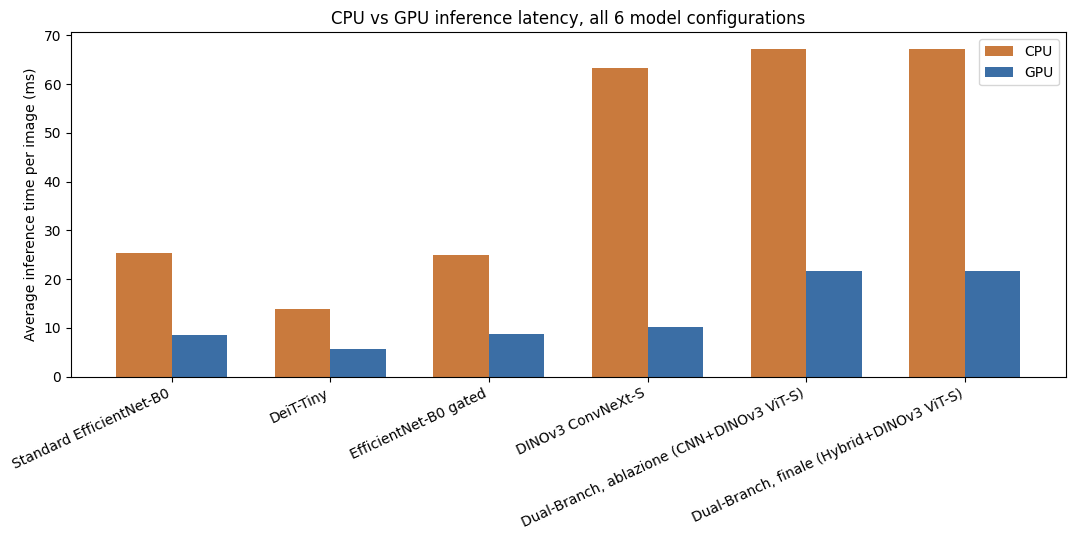


Saved: all_models_cpu_gpu_benchmark.png, all_models_cpu_gpu_benchmark.csv


In [4]:
def benchmark_inference(model, device, n_warmup=15, n_runs=100, image_size=224):
    model = model.to(device).eval()
    dummy_input = torch.randn(1, 3, image_size, image_size, device=device)

    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(dummy_input)
    if device.type == "cuda":
        torch.cuda.synchronize()

    times_ms = []
    with torch.no_grad():
        for _ in range(n_runs):
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(dummy_input)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            times_ms.append((t1 - t0) * 1000)

    times_ms = np.array(times_ms)
    return times_ms.mean(), times_ms.std()


model_constructors = {
    "Standard EfficientNet-B0": StandardEfficientNet,
    "DeiT-Tiny": DeitTiny,
    "EfficientNet-B0 gated": HybridEfficientNet,
    "DINOv3 ConvNeXt-S": DINOv3ConvNeXtClassifier,
    "Dual-Branch, ablazione (CNN+DINOv3 ViT-S)": DualBranchDinoViTClassifier,
    "Dual-Branch, finale (Hybrid+DINOv3 ViT-S)": HybridDinoViTClassifier,
}

results = []
for name, ctor in model_constructors.items():
    print(f"\nBenchmarking: {name}")
    model = ctor()

    cpu_mean, cpu_std = benchmark_inference(model, torch.device("cpu"))
    print(f"  CPU -> {cpu_mean:.1f} ms/image (+/- {cpu_std:.1f})")

    row = {"Model": name, "CPU (ms)": cpu_mean, "CPU std": cpu_std}

    if torch.cuda.is_available():
        gpu_mean, gpu_std = benchmark_inference(model, torch.device("cuda"))
        print(f"  GPU -> {gpu_mean:.1f} ms/image (+/- {gpu_std:.1f})")
        row["GPU (ms)"] = gpu_mean
        row["GPU std"] = gpu_std
        row["Speedup"] = cpu_mean / gpu_mean

    results.append(row)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(results_df)

# Bar chart for the thesis figure
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width / 2, results_df["CPU (ms)"], width, label="CPU", color="#c97a3d")
if "GPU (ms)" in results_df.columns:
    ax.bar(x + width / 2, results_df["GPU (ms)"], width, label="GPU", color="#3b6ea5")

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=25, ha="right")
ax.set_ylabel("Average inference time per image (ms)")
ax.set_title("CPU vs GPU inference latency, all 6 model configurations")
ax.legend()
plt.tight_layout()
plt.savefig("all_models_cpu_gpu_benchmark.png", dpi=200)
plt.show()

results_df.to_csv("all_models_cpu_gpu_benchmark.csv", index=False)
print("\nSaved: all_models_cpu_gpu_benchmark.png, all_models_cpu_gpu_benchmark.csv")